In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smart_meter_data.csv")

In [3]:
df

,datetime,msn,location,daily_consumption_load,energy_supplied,energy_billed
0,2021-01-01 00:00:00,ACE43B7D,Chennai,2.59,2.78,2.57
1,2021-01-01 00:15:00,ACE43B7D,Chennai,1.78,2.12,1.86
2,2021-01-01 00:30:00,ACE43B7D,Chennai,2.59,2.68,2.52
3,2021-01-01 00:45:00,ACE43B7D,Chennai,2.45,2.56,2.50
4,2021-01-01 01:00:00,ACE43B7D,Chennai,1.48,1.56,1.49
...,...,...,...,...,...,...
525595,2023-12-31 22:45:00,3F42A75F,Mumbai,3.38,3.59,3.26
525596,2023-12-31 23:00:00,3F42A75F,Mumbai,0.54,0.61,0.56
525597,2023-12-31 23:15:00,3F42A75F,Mumbai,1.29,1.33,1.32
525598,2023-12-31 23:30:00,3F42A75F,Mumbai,2.34,2.61,2.41


In [23]:
#convert to datetime
df['datetime'] = pd.to_datetime(df['datetime'])

In [7]:
df.nunique()

,0
datetime,105120
msn,5
location,5
daily_consumption_load,482
energy_supplied,451
energy_billed,458


In [8]:
df.describe()

,daily_consumption_load,energy_supplied,energy_billed
count,525600.000000,525600.000000,525600.000000
mean,2.542772,2.748650,2.542735
std,1.213020,1.300398,1.210173
min,0.410000,0.500000,0.430000
25%,1.490000,1.620000,1.490000
50%,2.540000,2.750000,2.540000
75%,3.570000,3.880000,3.580000
max,5.230000,5.000000,5.000000


In [9]:
df.isnull().sum()

,0
datetime,0
msn,0
location,0
daily_consumption_load,0
energy_supplied,0
energy_billed,0


In [10]:
df_num = df.select_dtypes(include=['int', 'float'])

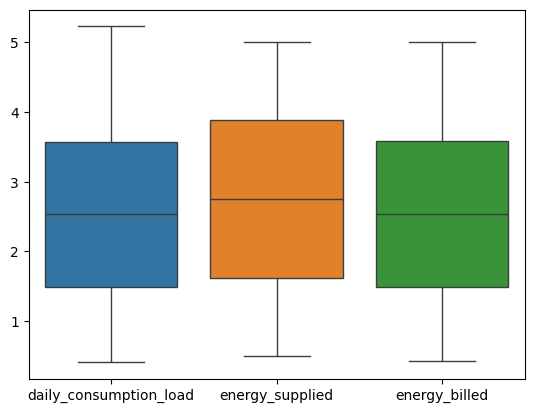

In [12]:
#box plot to check outlier
sns.boxplot(data=df_num)
plt.show()

## Bivariate analysis

<Axes: >

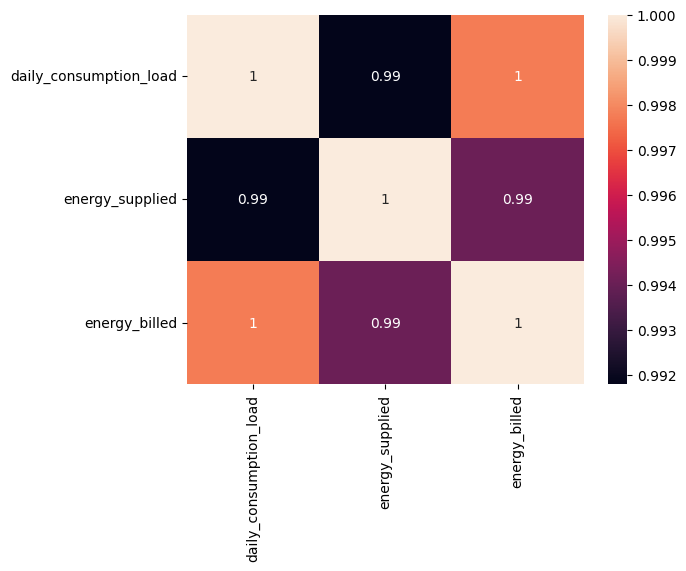

In [13]:
sns.heatmap(df_num.corr(), annot = True)

In [15]:
df["datetime"].min(), df["datetime"].max()

('2021-01-01 00:00:00', '2023-12-31 23:45:00')

<Axes: xlabel='energy_supplied', ylabel='Count'>

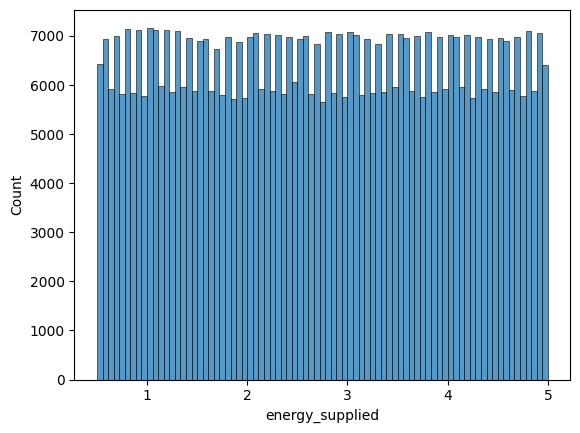

In [16]:
sns.histplot(df["energy_supplied"])

<Axes: xlabel='daily_consumption_load', ylabel='Count'>

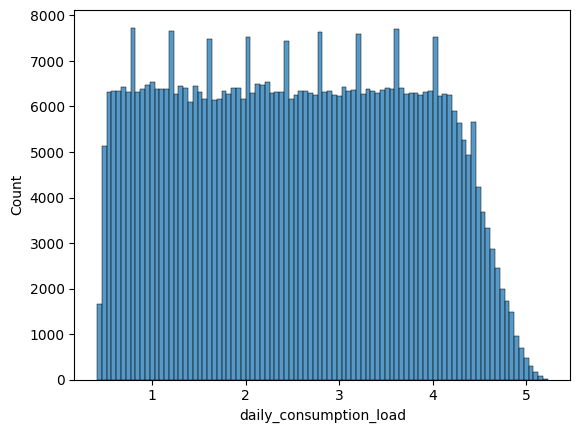

In [17]:
sns.histplot(df["daily_consumption_load"])

<Axes: xlabel='energy_billed', ylabel='Count'>

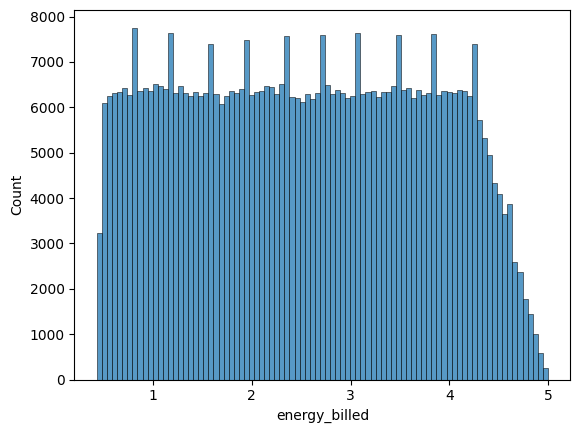

In [18]:
sns.histplot(df["energy_billed"])

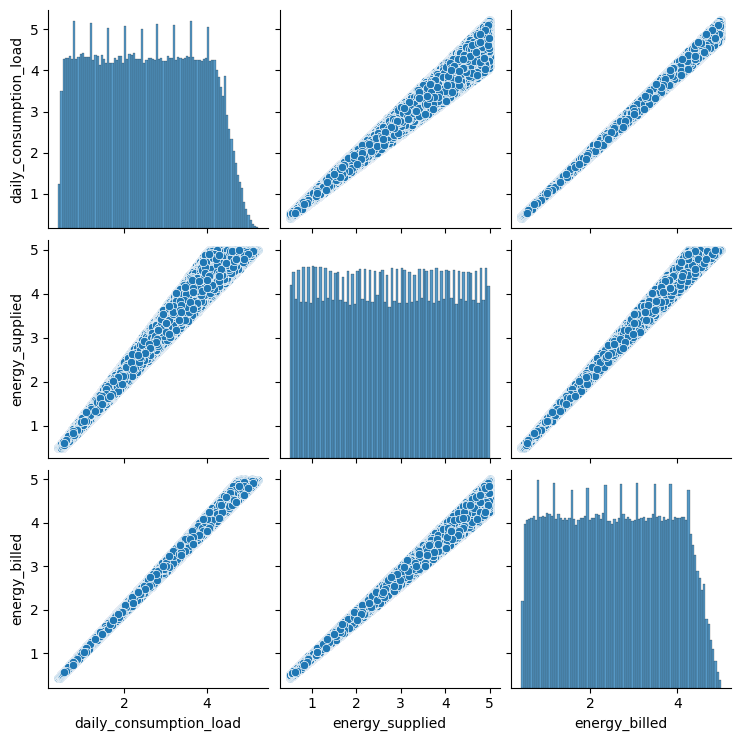

In [19]:
sns.pairplot(df_num)

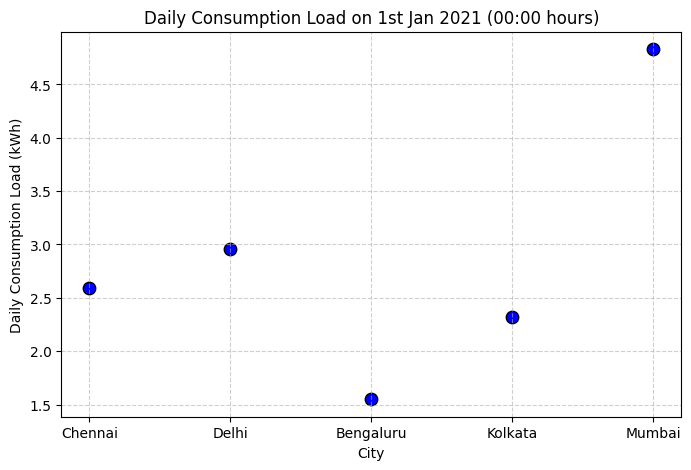

In [20]:
df_filtered = df[df['datetime'] == '2021-01-01 00:00:00']

# Scatter plot: city vs daily_consumption_load
plt.figure(figsize=(8,5))
plt.scatter(df_filtered['location'], df_filtered['daily_consumption_load'], color='blue', s=80, edgecolor='black')

plt.title('Daily Consumption Load on 1st Jan 2021 (00:00 hours)')
plt.xlabel('City')
plt.ylabel('Daily Consumption Load (kWh)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

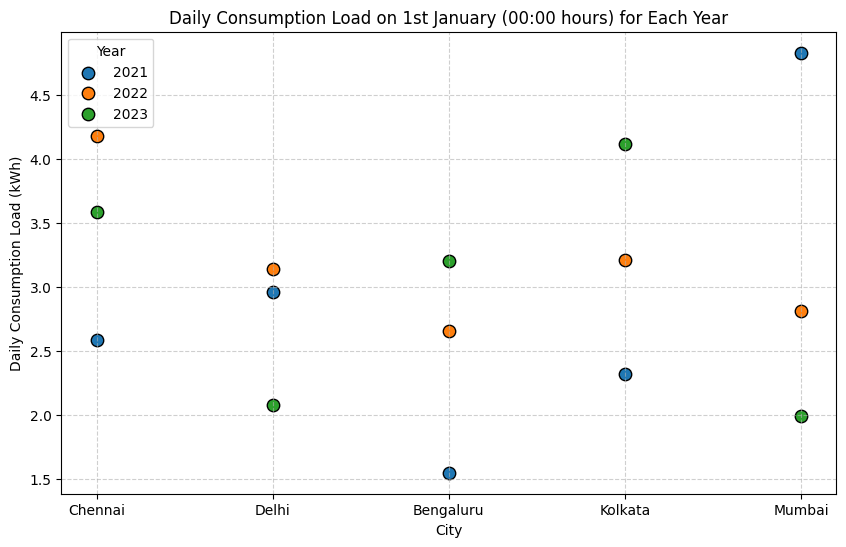

In [34]:

# Filter only rows where it's 1st Jan and time is 00:00:00
df_filtered = df[(df['datetime'].dt.month == 1) &
                 (df['datetime'].dt.day == 1) &
                 (df['datetime'].dt.hour == 0) &
                 (df['datetime'].dt.minute == 0)]

# Create scatter plot
plt.figure(figsize=(10,6))
for year, data in df_filtered.groupby('year'):
    plt.scatter(data['location'], data['daily_consumption_load'], label=str(year), s=80, edgecolor='black')

plt.title('Daily Consumption Load on 1st January (00:00 hours) for Each Year')
plt.xlabel('City')
plt.ylabel('Daily Consumption Load (kWh)')
plt.legend(title='Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [35]:
jan_sum_city_year = (
    df[df['datetime'].dt.month == 1]
    .groupby([df['datetime'].dt.year, 'location'])['daily_consumption_load']
    .sum()
    .reset_index(name='total_jan_load')
)

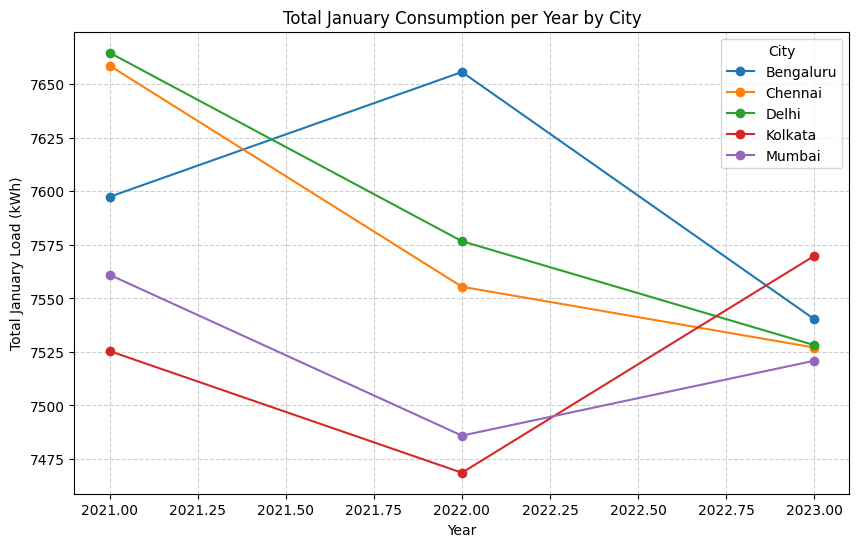

In [36]:
plt.figure(figsize=(10,6))
for city, data in jan_sum_city_year.groupby('location'):
    plt.plot(data['datetime'], data['total_jan_load'], marker='o', label=city)

plt.title('Total January Consumption per Year by City')
plt.xlabel('Year')
plt.ylabel('Total January Load (kWh)')
plt.legend(title='City')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [37]:
df

,datetime,msn,location,daily_consumption_load,energy_supplied,energy_billed,year,time
0,2021-01-01 00:00:00,ACE43B7D,Chennai,2.59,2.78,2.57,2021,00:00:00
1,2021-01-01 00:15:00,ACE43B7D,Chennai,1.78,2.12,1.86,2021,00:15:00
2,2021-01-01 00:30:00,ACE43B7D,Chennai,2.59,2.68,2.52,2021,00:30:00
3,2021-01-01 00:45:00,ACE43B7D,Chennai,2.45,2.56,2.50,2021,00:45:00
4,2021-01-01 01:00:00,ACE43B7D,Chennai,1.48,1.56,1.49,2021,01:00:00
...,...,...,...,...,...,...,...,...
525595,2023-12-31 22:45:00,3F42A75F,Mumbai,3.38,3.59,3.26,2023,22:45:00
525596,2023-12-31 23:00:00,3F42A75F,Mumbai,0.54,0.61,0.56,2023,23:00:00
525597,2023-12-31 23:15:00,3F42A75F,Mumbai,1.29,1.33,1.32,2023,23:15:00
525598,2023-12-31 23:30:00,3F42A75F,Mumbai,2.34,2.61,2.41,2023,23:30:00


In [38]:
data['total_jan_load']

,total_jan_load
4,7561.03
9,7485.91
14,7520.88
